In [6]:
from nba_api.stats.endpoints import leaguehustlestatsplayer
from nba_api.stats.endpoints import playergamelogs
import pandas as pd
# Requesting league-wide player tracking camera metrics
logs = leaguehustlestatsplayer.LeagueHustleStatsPlayer(
    season="2024-25",
    season_type_all_star="Regular Season",
)
base_df = playergamelogs.PlayerGameLogs(season_nullable="2024-25", season_type_nullable="Regular Season").get_data_frames()[0]

tracking_df = logs.get_data_frames()[0]
hustle_lookup = tracking_df[['PLAYER_ID', 'BOX_OUTS']]

combined_df = pd.merge(
    base_df, 
    hustle_lookup, 
    on='PLAYER_ID', 
    how='inner'
)
print(tracking_df.columns.tolist())

['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'G', 'MIN', 'CONTESTED_SHOTS', 'CONTESTED_SHOTS_2PT', 'CONTESTED_SHOTS_3PT', 'DEFLECTIONS', 'CHARGES_DRAWN', 'SCREEN_ASSISTS', 'SCREEN_AST_PTS', 'OFF_LOOSE_BALLS_RECOVERED', 'DEF_LOOSE_BALLS_RECOVERED', 'LOOSE_BALLS_RECOVERED', 'PCT_LOOSE_BALLS_RECOVERED_OFF', 'PCT_LOOSE_BALLS_RECOVERED_DEF', 'OFF_BOXOUTS', 'DEF_BOXOUTS', 'BOX_OUT_PLAYER_TEAM_REBS', 'BOX_OUT_PLAYER_REBS', 'BOX_OUTS', 'PCT_BOX_OUTS_OFF', 'PCT_BOX_OUTS_DEF', 'PCT_BOX_OUTS_TEAM_REB', 'PCT_BOX_OUTS_REB']


Base Shape: (26302, 71)
Final Joined Shape: (26302, 71)
Missing Values:
 BOX_OUTS    0
REB         0
dtype: int64


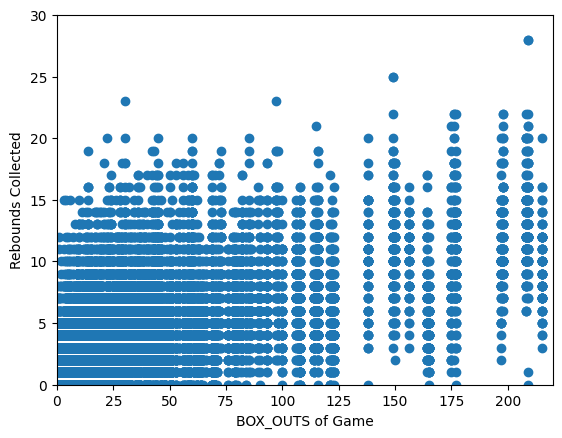

Correlation: 0.5366017962572478
R2 Score: 0.2879414877465053


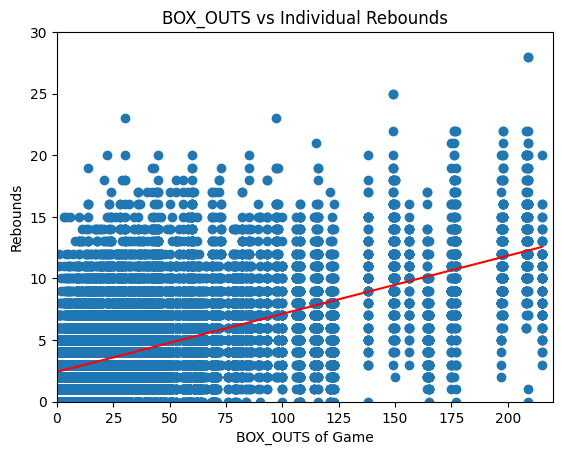

In [11]:
# Create your clean analytics sandbox slice
import pandas as pd
from sklearn.linear_model import LinearRegression
from matplotlib import pyplot as plt
chances_reb = combined_df[["BOX_OUTS", "REB"]]
print("Base Shape:", combined_df.shape)
print("Final Joined Shape:", combined_df.shape)
print("Missing Values:\n", chances_reb.isnull().sum())

plt.scatter(chances_reb["BOX_OUTS"], chances_reb["REB"])
plt.xlim(0, 220) # Adjusted boundaries to match real team-wide miss distributions
plt.ylim(0, 30)
plt.xlabel("BOX_OUTS of Game")
plt.ylabel("Rebounds Collected")
plt.show()

print("Correlation:", chances_reb["BOX_OUTS"].corr(chances_reb["REB"]))

# 5. Initialize, Fit, and Execute your Machine Learning Regression
X = chances_reb[["BOX_OUTS"]]
y = chances_reb["REB"]

model = LinearRegression()
model.fit(X, y) # Fit the brain first!
r2 = model.score(X, y)
print("R2 Score:", r2)

# 6. Sort your feature matrix sequentially to draw a crisp trend line
X_sorted = X.sort_values("BOX_OUTS")
predictions_sorted = model.predict(X_sorted)

# 7. Generate your final diagnostic report visualization
plt.scatter(chances_reb["BOX_OUTS"], chances_reb["REB"])
plt.plot(X_sorted["BOX_OUTS"], predictions_sorted, color="red") 

plt.xlim(0, 220)
plt.ylim(0, 30)
plt.xlabel("BOX_OUTS of Game")
plt.ylabel("Rebounds")
plt.title("BOX_OUTS vs Individual Rebounds")
plt.show()


In [ ]:
"""Feature: BOX_OUTS (Player Box Outs per Game)

Relationship: 
Strong positive relationship with raw REB totals.

Correlation: 
0.5366

R²: 
0.2879

Why it matters / Basketball Logic: 
A massive statistical indicator for interior positioning and fundamental play. 
Players who actively shield opponents from the glass via box outs put themselves 
(and their teammates) in an elite physical position to secure the ball. 

Pregame usable? 
No, must be calculated using historical rolling averages (EWMA Last 5/10 games).

Potential future use: 
High priority predictive anchor. This tracking metric helps the model differentiate 
between empty athletic jumpers and structurally disciplined, high-rebounding interior 
big men who consistently establish leverage in the paint.
"""